# 🛍️ Customer Segmentation using K-Means Clustering

This project applies unsupervised machine learning to segment mall customers based on their annual income and spending behaviour. The objective is to uncover hidden customer groups and generate actionable marketing insights.

## 🎯 Project Objective

- Understand customer behavioural patterns
- Identify distinct customer segments
- Provide data-driven marketing recommendations

In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

In [2]:
#Importing Dataset
data = pd.read_csv(r"C:\Users\DELL LATITUDE\OneDrive\Attachments\Application Data\Desktop\SQL Assignment\Mall_Customers.csv")
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


EXPLORING THE  DATA

In [3]:
#Checking Dataset structure and summary statistics 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
data.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 🧹 Data Cleaning

The column *Genre* was renamed to *Gender* for clarity.  
No missing values or duplicates were observed.

In [5]:
# Rename column for better interpretability
data.rename(columns={'Genre':'Gender'}, inplace=True)

## 📊 Exploratory Data Analysis

EDA was conducted to understand customer distribution, behavioural relationships, and potential segmentation patterns.

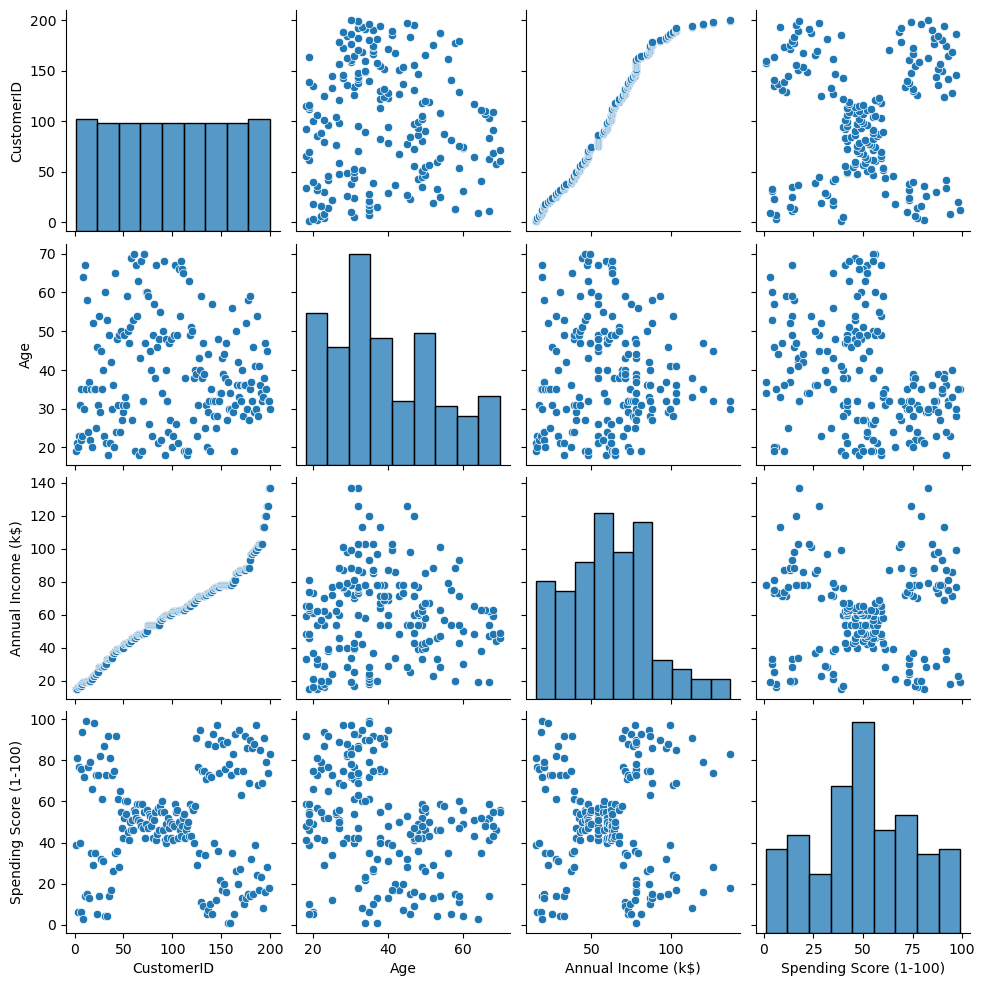

In [6]:
#Pairwise relationships between features
sns.pairplot(data)
plt.show()

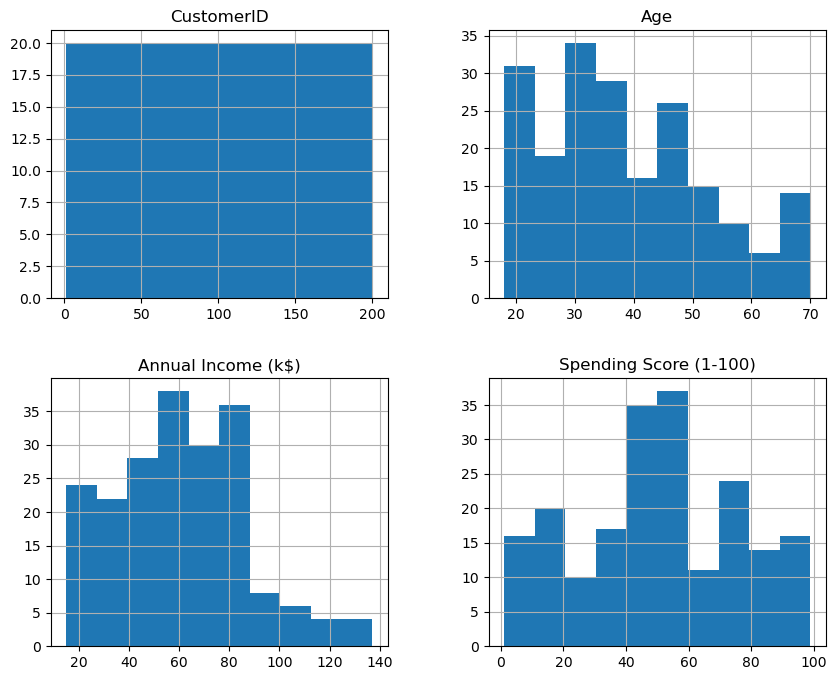

In [7]:
data.hist(figsize=(10,8))
plt.show()

KDE Curve

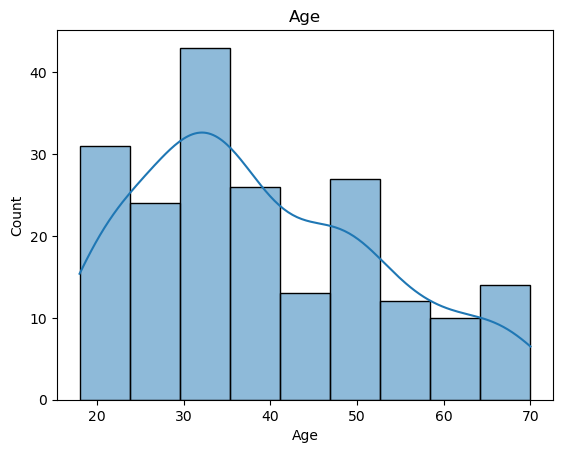

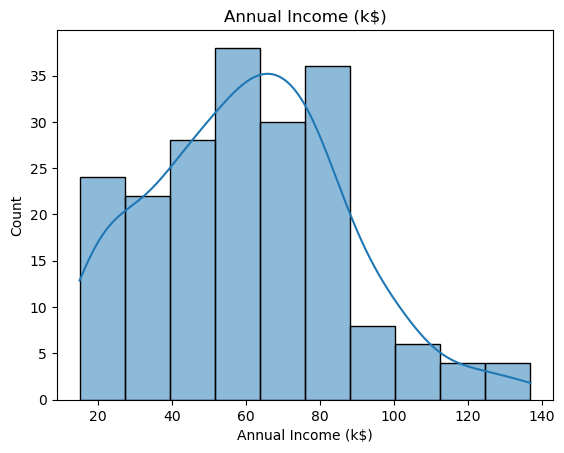

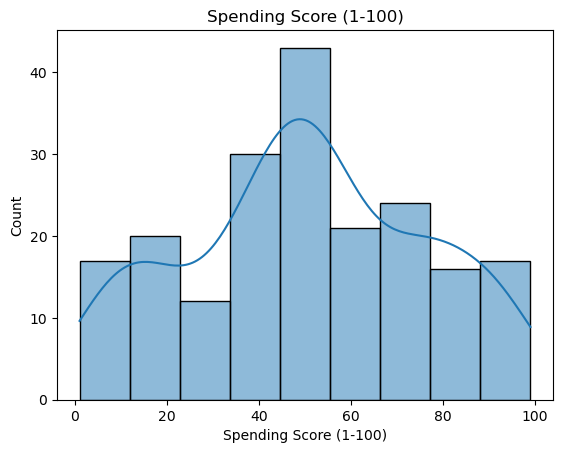

In [8]:
for col in ['Age','Annual Income (k$)','Spending Score (1-100)']:
    plt.figure()
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

Bivariate Relationship

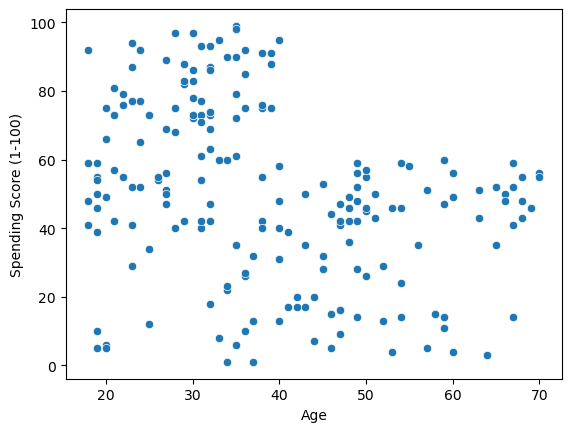

In [9]:
sns.scatterplot(x="Age", y = "Spending Score (1-100)", data = data)
plt.show()

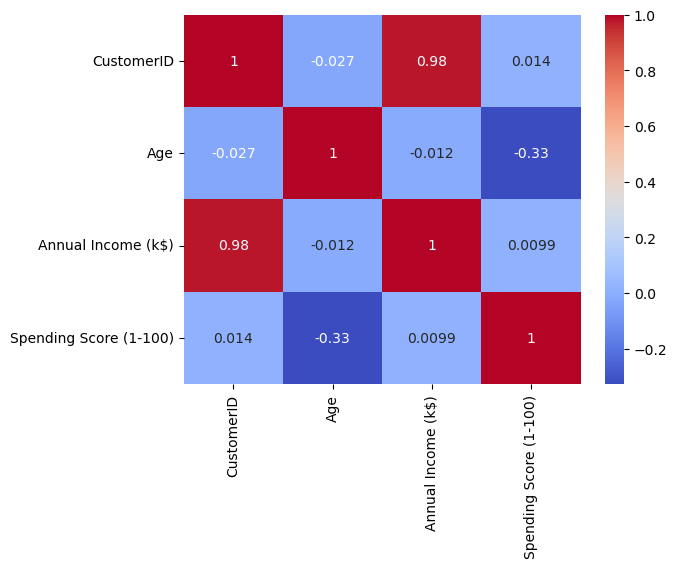

In [10]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

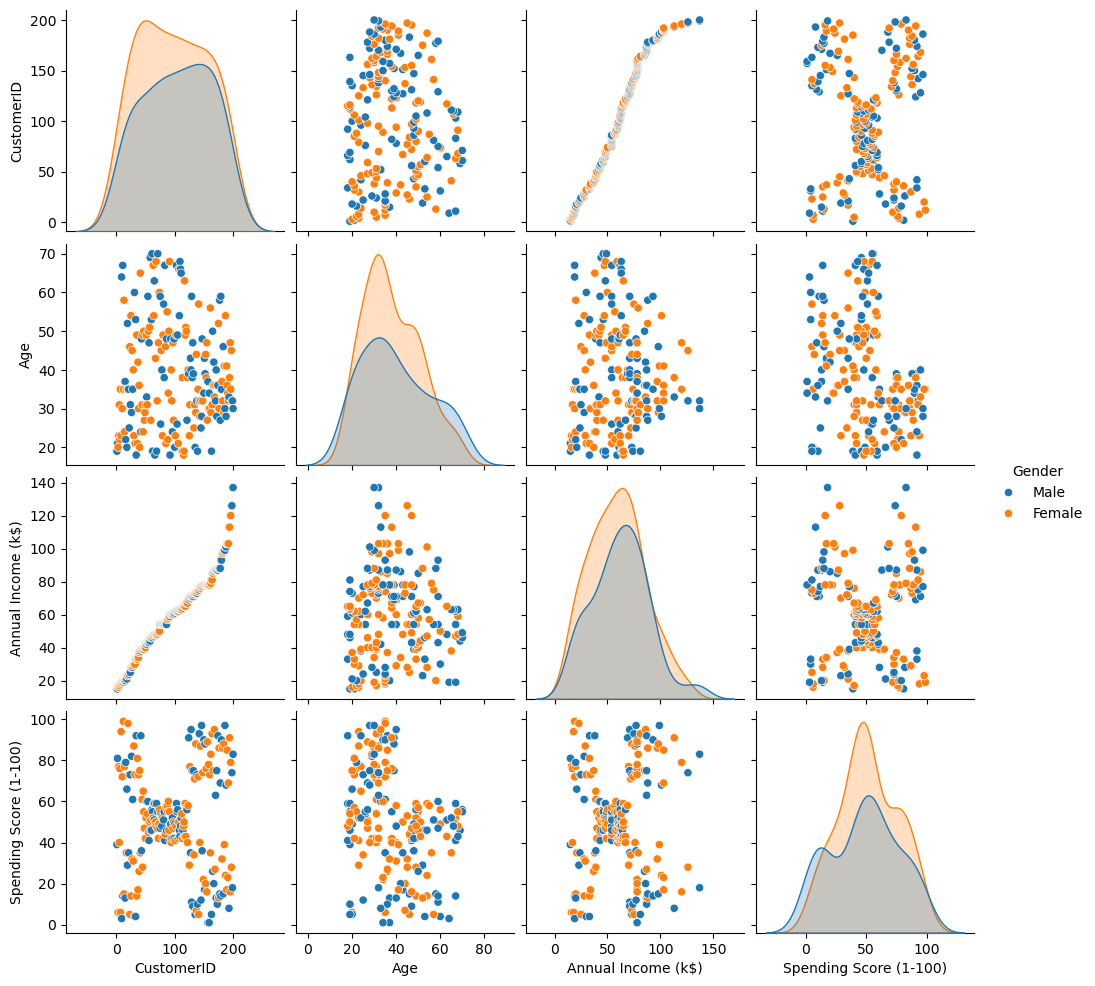

In [11]:
sns.pairplot(data, hue='Gender')
plt.show()

UNSUPERVISED LEARNING

## 🎯 Feature Selection

Customer segmentation was performed using **Annual Income** and **Spending Score** as they capture financial capacity and purchasing behaviour.

In [12]:
#Selecting Behavioural Features for clustering
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

## ⚖️ Feature Scaling

Standardization was applied to ensure both features contribute equally to distance-based clustering.

In [13]:
#Scalinng features for KMeans
scaler = StandardScaler()
num_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(num_scaled, columns=X.columns)
X_scaled

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


## 📉 Optimal Cluster Selection (Elbow Method)

The elbow method was used to determine the optimal number of clusters by analyzing WCSS reduction across different K values.

C:\Users\DELL LATITUDE\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL LATITUDE\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL LATITUDE\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL LATITUDE\AppData\Roaming\Python\Python312

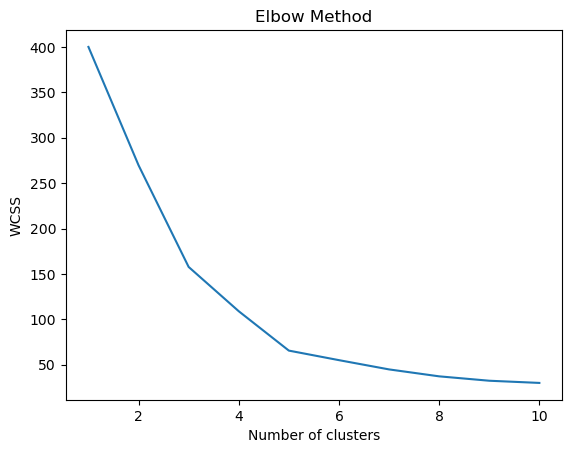

In [14]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

The elbow curve showed noticeable bends around K = 3 and K = 5.
While K = 3 produced broader segments, K = 5 provided more granular and meaningful customer groups.
Therefore, K = 5 was selected as the optimal number of clusters.

## 🤖 K-Means Clustering

K = 5 was selected to achieve meaningful customer segmentation.

In [15]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster = kmeans.fit_predict(X_scaled)

data['Cluster'] = cluster

C:\Users\DELL LATITUDE\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 🎨 Cluster Visualization

Customer groups were visualized in a 2D behavioural space to interpret segment characteristics.

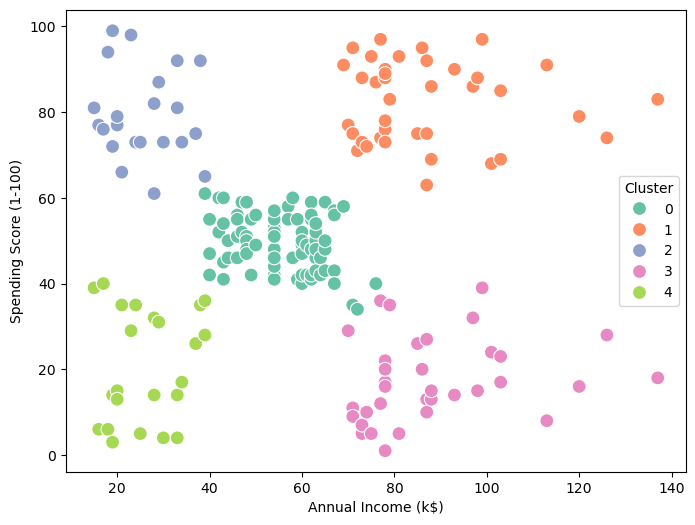

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x = "Annual Income (k$)",
    y = "Spending Score (1-100)",
    hue = "Cluster",
    palette= "Set2",
    data= data,
    s = 100
)



plt.show()

## 🧠 Customer Segment Insights
<p></p>

🟠 **Orange cluster (Premium Customers)**
<p>👉 High income and high spending customers representing the most valuable segment.</p>


🔵 **Blue cluster (Impulsive Buyers)**
<p>👉 Low income but high spending customers showing emotionally driven purchasing behaviour.</p>


🟢 **Teal/Green cluster (Average Customers)**
<p>👉 Moderate income and spending customers forming the largest and most stable segment.</p>


🌸 **Purple cluster (Potential Customers)**
<p>👉 High income but low spending customers representing strong upselling opportunities.</p>


🟩 **Light-green cluster (Budget Customers)**
<p>👉Low income and low spending customers exhibiting minimal engagement.</p>

## 💼 Business Recommendations

### 🎯 Premium Customers
- Implement loyalty and VIP reward programs  
- Provide early access to new products  
- Offer personalized premium experiences  

### 📈 Potential Customers (High income, low spending)
- Deploy targeted upselling campaigns  
- Use personalized recommendations  
- Introduce exclusive bundles and incentives  

### 💥 Impulsive Buyers
- Leverage flash sales and limited-time offers  
- Provide installment-based purchasing options  
- Use emotional marketing strategies  

### ⚖️ Average Customers
- Focus on cross-selling and retention campaigns  
- Offer seasonal promotions  
- Maintain consistent engagement  

### 💰 Budget Customers
- Promote discounted products and value bundles  
- Encourage engagement through promotions  
- Avoid heavy marketing spend due to low ROI

## ✅ Conclusion

K-Means clustering successfully identified five distinct customer segments.  
The insights derived from these segments can support targeted marketing, improved customer engagement, and optimized revenue strategies.

## 🔬 Bonus: Density-Based Clustering with DBSCAN

To further explore customer segmentation, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) was applied as an alternative to K-Means.  

Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand and is capable of identifying noise or outlier customers. This provides additional insight into customer behaviour and helps validate the robustness of the segmentation results.

In [17]:
dbscan= DBSCAN(eps=0.3, min_samples=5)
db_clusters= dbscan.fit_predict(X_scaled)

data["DBSCAN"] = db_clusters

To Visualize DBSCAN Clusters

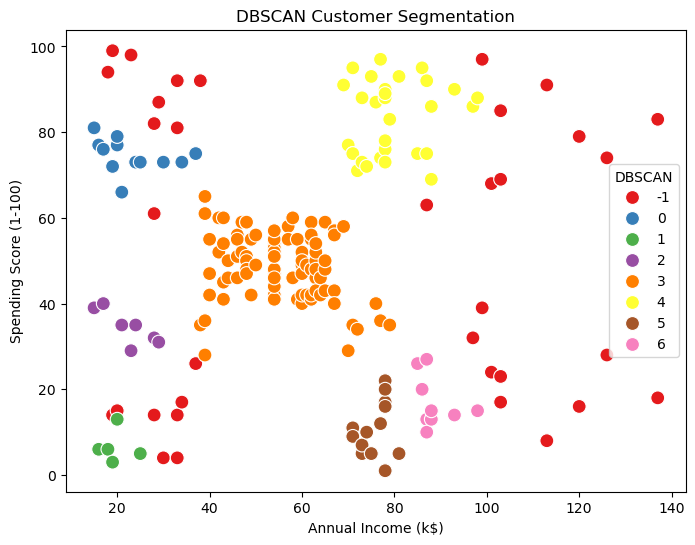

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="DBSCAN",
    palette="Set1",
    data=data,
    s=100
)

plt.title("DBSCAN Customer Segmentation")
plt.show()

## 🔬 DBSCAN Clustering Interpretation

DBSCAN produced multiple customer groupings based on density and identified several customers as noise (labelled **-1**). These noise points represent customers whose behaviour does not strongly belong to any dominant segment.

### Key Observations

**Core Customer Groups**  
Several dense clusters were detected, representing customers with similar income and spending behaviour. These clusters align broadly with the K-Means segmentation, confirming the presence of meaningful behavioural patterns.

**Average Behaviour Cluster**  
A large dense cluster was observed around medium income and moderate spending levels, representing the most stable and typical customer group.

**High-Value Segment**  
Customers with high income and high spending formed a distinct dense region, reinforcing the presence of a premium customer segment.

**Low-Spending Segments**  
Smaller dense clusters appeared among customers with low spending scores, indicating budget-conscious and low-engagement groups.

**Noise / Outliers (-1)**  
A significant number of customers were labelled as noise. These customers exhibit unusual purchasing patterns and may represent:
- inconsistent buying behaviour
- occasional luxury shoppers
- potential data anomalies
- niche customer profiles

### Business Insight

The presence of noise highlights customers with unpredictable behaviour. These individuals may require personalized engagement strategies rather than broad marketing campaigns.

Compared to K-Means, DBSCAN provides additional value by identifying outlier customers and validating the stability of the primary customer segments.
